# Support Vector Machine (SVM) - Loan Default Prediction

This notebook trains and evaluates an SVM classifier for loan default prediction using your processed train and test datasets.

Workflow:
1. Load processed data
2. Build SVM baseline model
3. Tune hyperparameters with cross-validation
4. Evaluate and compare baseline vs tuned model
5. Save outputs (metrics, CV results, trained model)

In [13]:
# Imports
from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

warnings.filterwarnings("ignore")
print("Imports successful.")

Imports successful.


In [14]:
# Resolve project paths so this notebook works from either repo root or notebooks folder
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "dataset" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = RESULTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_ROOT: e:\Y4S1_Projects\ML_Assignment\MLproject
DATA_DIR: e:\Y4S1_Projects\ML_Assignment\MLproject\dataset\processed
RESULTS_DIR: e:\Y4S1_Projects\ML_Assignment\MLproject\results


In [15]:
# Import reusable evaluation helpers from src/evaluation.py
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve, compare_models

In [16]:
# Load processed train and test datasets
train_path = DATA_DIR / "train_preprocessed_smote.csv"
test_path = DATA_DIR / "test_preprocessed.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

if "Default" not in train_df.columns or "Default" not in test_df.columns:
    raise ValueError("Expected target column 'Default' not found in train/test data.")

Train shape: (14188, 23)
Test shape : (2000, 23)


In [17]:
# Split into features and target
X_train = train_df.drop(columns=["Default"])
y_train = train_df["Default"]

X_test = test_df.drop(columns=["Default"])
y_test = test_df["Default"]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).rename("ratio"))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).rename("ratio"))

X_train: (14188, 22) | y_train: (14188,)
X_test : (2000, 22) | y_test : (2000,)

Train class distribution:
Default
1    0.5
0    0.5
Name: ratio, dtype: float64

Test class distribution:
Default
0    0.8865
1    0.1135
Name: ratio, dtype: float64


## 1) Baseline SVM

We start with a strong baseline using RBF kernel and `class_weight='balanced'`.

In [18]:
# Baseline SVM pipeline
baseline_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# Train baseline on the full training data
baseline_svm.fit(X_train, y_train)

y_pred_baseline = baseline_svm.predict(X_test)
y_prob_baseline = baseline_svm.predict_proba(X_test)[:, 1]

metrics_baseline = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_baseline,
    y_prob=y_prob_baseline,
    model_name="SVM Baseline"
)


SVM Baseline Evaluation Results
ACCURACY    : 0.8155
PRECISION   : 0.2710
RECALL      : 0.3700
F1_SCORE    : 0.3128
AUC_ROC     : 0.6756

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      0.87      0.89      1773
     Default       0.27      0.37      0.31       227

    accuracy                           0.82      2000
   macro avg       0.59      0.62      0.60      2000
weighted avg       0.84      0.82      0.83      2000



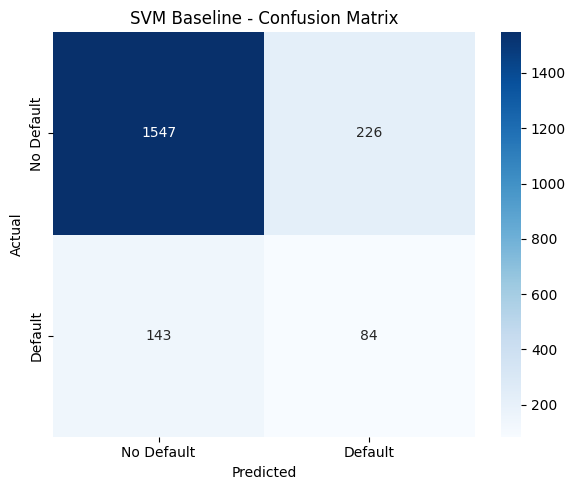

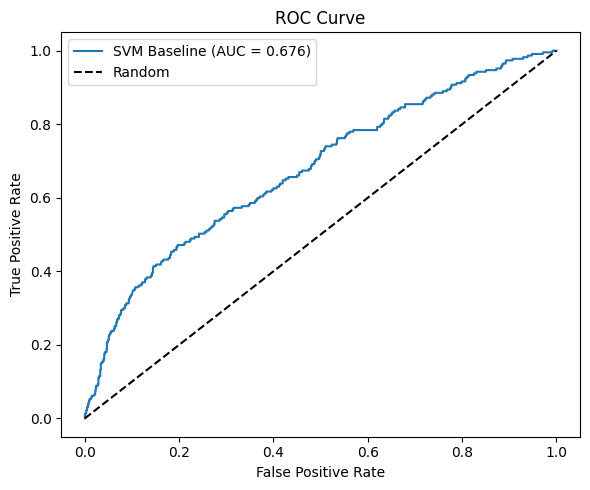

In [21]:
# Baseline visual diagnostics
_ = plot_confusion_matrix(y_test, y_pred_baseline, model_name="SVM Baseline")
_ = plot_roc_curve(y_test, y_prob_baseline, model_name="SVM Baseline")

## 2) Hyperparameter Tuning (Fast RandomizedSearchCV)

This section is optimized for speed: tune on a sampled training subset with fewer CV folds and fewer sampled combinations.

In [22]:
# Hyperparameter tuning using RandomizedSearchCV on full training data

# Tune on the full training set
X_train_tune = X_train
y_train_tune = y_train
print(f"Tuning sample size: {X_train_tune.shape[0]} rows")

# Use compact candidate pools
param_distributions = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": np.logspace(-1, 1.5, 8).tolist(),
    "svm__gamma": ["scale", 0.01, 0.1]
}

# Use 2-fold CV for speed
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# SVC settings during search
svm_for_tuning = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(
        class_weight="balanced",
        probability=False,
        tol=1e-2,
        max_iter=1500,
        random_state=42
    ))
])

random_search = RandomizedSearchCV(
    estimator=svm_for_tuning,
    param_distributions=param_distributions,
    n_iter=4,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_tune, y_train_tune)

print("Best params (full data):", random_search.best_params_)
print(f"Best CV F1: {random_search.best_score_:.4f}")

# Refit final model with probability=True for ROC/AUC analysis
best_params = random_search.best_params_
best_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel=best_params["svm__kernel"],
        C=best_params["svm__C"],
        gamma=best_params["svm__gamma"] if best_params["svm__kernel"] == "rbf" else "scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# Fit the final tuned model on the full training data
best_svm.fit(X_train, y_train)

Tuning sample size: 14188 rows
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best params (full data): {'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__C': 31.622776601683793}
Best CV F1: 0.8934


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",31.622776601683793
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [23]:
# Evaluate tuned model on test data
y_pred_tuned = best_svm.predict(X_test)
y_prob_tuned = best_svm.predict_proba(X_test)[:, 1]

metrics_tuned = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_tuned,
    y_prob=y_prob_tuned,
    model_name="SVM Tuned"
 )


SVM Tuned Evaluation Results
ACCURACY    : 0.8310
PRECISION   : 0.1864
RECALL      : 0.1454
F1_SCORE    : 0.1634
AUC_ROC     : 0.6066

Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.92      0.91      1773
     Default       0.19      0.15      0.16       227

    accuracy                           0.83      2000
   macro avg       0.54      0.53      0.53      2000
weighted avg       0.81      0.83      0.82      2000



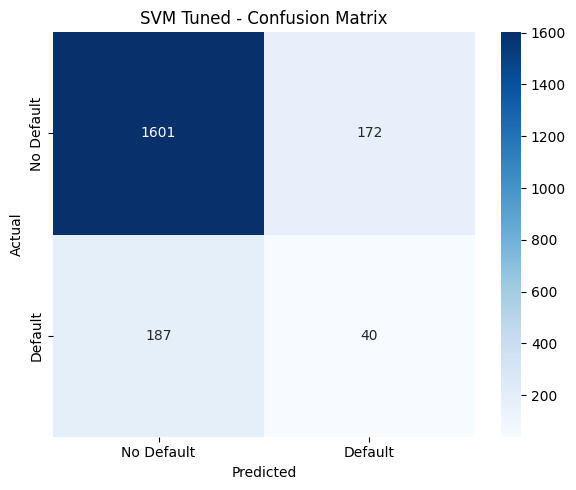

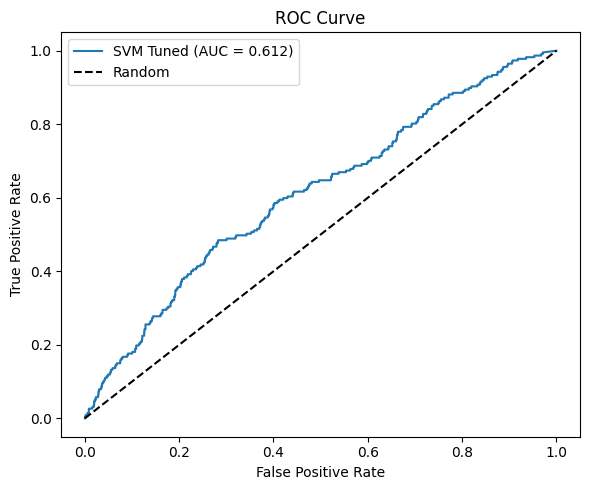

In [ ]:
# Tuned model diagnostics
_ = plot_confusion_matrix(y_test, y_pred_tuned, model_name="SVM Tuned")
_ = plot_roc_curve(y_test, y_prob_tuned, model_name="SVM Tuned")

## 3) Comparison and Export

In [24]:
# Compare baseline vs tuned metrics
results_dict = {
    "SVM_Baseline": metrics_baseline,
    "SVM_Tuned": metrics_tuned
}

comparison_df = compare_models(results_dict)
comparison_df


Model Comparison
              accuracy  precision  recall  f1_score  auc_roc
SVM_Baseline    0.8155     0.2710  0.3700    0.3128   0.6756
SVM_Tuned       0.8310     0.1864  0.1454    0.1634   0.6066


,accuracy,precision,recall,f1_score,auc_roc
SVM_Baseline,0.8155,0.2710,0.3700,0.3128,0.6756
SVM_Tuned,0.8310,0.1864,0.1454,0.1634,0.6066


In [25]:
# Save comparison metrics
svm_metrics_path = RESULTS_DIR / "svm_metrics_comparison.csv"
comparison_df.to_csv(svm_metrics_path, index=True)
print("Saved metrics to:", svm_metrics_path)

Saved metrics to: e:\Y4S1_Projects\ML_Assignment\MLproject\results\svm_metrics_comparison.csv


In [26]:
# Save CV search results (top configurations)
cv_results = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
cv_results_path = RESULTS_DIR / "svm_randomsearch_cv_results.csv"
cv_results.to_csv(cv_results_path, index=False)

display_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_svm__kernel",
    "param_svm__C",
    "param_svm__gamma"
]

print("Saved CV results to:", cv_results_path)
cv_results[display_columns].head(10)

Saved CV results to: e:\Y4S1_Projects\ML_Assignment\MLproject\results\svm_randomsearch_cv_results.csv


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_svm__kernel,param_svm__C,param_svm__gamma
3,1,0.893445,0.006227,0.969937,rbf,31.622777,scale
0,2,0.773932,0.002126,0.797113,rbf,2.682696,0.01
2,3,0.499042,0.012882,0.506970,linear,2.682696,0.01
1,4,0.491353,0.020572,0.504210,linear,13.894955,0.1


In [27]:
# Save final tuned model
model_path = MODELS_DIR / "svm_tuned_pipeline.joblib"
joblib.dump(best_svm, model_path)
print("Saved tuned model to:", model_path)

Saved tuned model to: e:\Y4S1_Projects\ML_Assignment\MLproject\results\models\svm_tuned_pipeline.joblib


## 4) Quick Inference Example

In [29]:
# Predict on first 5 test rows using saved model
loaded_model = joblib.load(model_path)
sample_X = X_test.head(5)
sample_pred = loaded_model.predict(sample_X)
sample_prob = loaded_model.predict_proba(sample_X)[:, 1]

pd.DataFrame({
    "predicted_class": sample_pred,
    "default_probability": np.round(sample_prob, 4)
}, index=sample_X.index)

,predicted_class,default_probability
0,0,0.0000
1,0,0.0000
2,0,0.0000
3,0,0.0035
4,0,0.0000
